# ISO 5167-2 orifice-plate metering with the common kernel

This example uses NeqSim's edition-aware `Iso5167OrificeMeteringKernel`. It applies the existing Reader-Harris/Gallagher equations through an immutable input, explicit liquid or gas/vapour service, and fail-closed applicability checks.

> **Boundary:** this is a regression-backed `SCREENING` calculation, not a conformity or custody-transfer assessment. The installation flag is an external attestation. Verify the purchased ISO 5167-1/-2 documents, plate and tapping geometry, straight lengths, calibration, uncertainty, pulsation, data quality, and project acceptance independently.

In [1]:
from pathlib import Path
import os
import sys
import jpype

ROOT = Path.cwd().resolve()
while not (ROOT / 'pom.xml').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
assert (ROOT / 'pom.xml').exists(), 'Run this notebook from the NeqSim repository tree'

if not jpype.isJVMStarted():
    local_classpath = os.environ.get('NEQSIM_NOTEBOOK_CLASSPATH')
    if local_classpath:
        jpype.startJVM(classpath=local_classpath.split(os.pathsep), convertStrings=True)
    else:
        sys.path.insert(0, str(ROOT / 'devtools'))
        from neqsim_dev_setup import neqsim_init
        neqsim_init(project_root=ROOT, recompile=not (ROOT / 'target/classes').exists(), verbose=False)

from jpype import JClass
import pandas as pd
import matplotlib.pyplot as plt
print('Workspace kernel loaded:', ROOT)

mkdir -p failed for path /root/.config/matplotlib: [Errno 30] Read-only file system: '/root/.config'
Matplotlib created a temporary cache directory at /tmp/matplotlib-tv6krfeb because there was an issue with the default path (/root/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.
Workspace kernel loaded: /workspace/scratch/de313162ffce/repo_iso5167


## 1. Explicit edition, service, and applicability basis

Every numerical builder method includes its unit. The Boolean values record the applicability and external installation basis that must exist before an ISO-labelled screening result is produced.

In [2]:
StandardType = JClass('neqsim.process.mechanicaldesign.designstandards.StandardType')
StandardEdition = JClass('neqsim.process.mechanicaldesign.designstandards.StandardEdition')
Kernel = JClass('neqsim.process.engineering.calculation.Iso5167OrificeMeteringKernel')
Input = JClass('neqsim.process.engineering.calculation.Iso5167OrificeMeteringKernel$Input')
ServiceType = JClass('neqsim.process.engineering.calculation.Iso5167OrificeMeteringKernel$ServiceType')
TapType = JClass('neqsim.process.engineering.calculation.Iso5167OrificeMeteringKernel$TapType')

edition = StandardEdition.defaultEdition(StandardType.ISO_5167_2)
kernel = Kernel()

def run_case(service, density, viscosity, kappa=None, installation_verified=True):
    builder = (Input.builder(edition, 'Orifice')
        .serviceType(service)
        .tapType(TapType.FLANGE)
        .pipeInternalDiameterM(0.100)
        .orificeBoreDiameterM(0.050)
        .upstreamPressurePaAbsolute(500000.0)
        .downstreamPressurePaAbsolute(480000.0)
        .upstreamDensityKgPerM3(density)
        .upstreamDynamicViscosityPaS(viscosity)
        .singlePhase(True)
        .conduitRunningFull(True)
        .subsonicThroughoutMeter(True)
        .pulsatingFlow(False)
        .geometryAndInstallationVerified(installation_verified))
    if kappa is not None:
        builder = builder.isentropicExponent(kappa)
    return kernel.calculate(builder.build(), None)

gas_result = run_case(ServiceType.GAS_OR_VAPOUR, 5.5, 1.2e-5, 1.30)
gas = gas_result.getValue()
summary = pd.Series({
    'status': str(gas_result.getStatus()),
    'Part 2 edition': str(gas.getStandardEdition()),
    'companion basis': str(gas.getCompanionStandardEdition()),
    'beta ratio [-]': float(gas.getBetaRatio()),
    'discharge coefficient [-]': float(gas.getDischargeCoefficient()),
    'expansibility factor [-]': float(gas.getExpansibilityFactor()),
    'mass flow [kg/s]': float(gas.getMassFlowRateKgPerS()),
    'actual flow [m3/s]': float(gas.getActualVolumeFlowRateM3PerS()),
    'pipe Reynolds number [-]': float(gas.getPipeReynoldsNumber()),
    'permanent pressure loss [Pa]': float(gas.getPermanentPressureLossPa()),
    'engineering approval required': bool(gas.toMap().get('engineeringApprovalRequired')),
})
summary.to_frame('screening result')

,screening result
status,CALCULATED_REVIEW_REQUIRED
Part 2 edition,ISO-5167-2 2022
companion basis,ISO-5167-1 2022
beta ratio [-],0.5
discharge coefficient [-],0.603549
expansibility factor [-],0.988542
mass flow [kg/s],0.567497
actual flow [m3/s],0.103181
pipe Reynolds number [-],602132.908145
permanent pressure loss [Pa],14662.727836


## 2. Liquid versus gas/vapour service

Liquid service sets expansibility to exactly one. Gas/vapour service applies the pressure-ratio and kappa correction. The comparison below is illustrative because the supplied densities represent different fluids.

,service,epsilon [-],mass flow [kg/s],Re_D [-]
0,liquid,1.000000,7.767376,98897.306948
1,gas/vapour,0.988542,0.567497,602132.908145


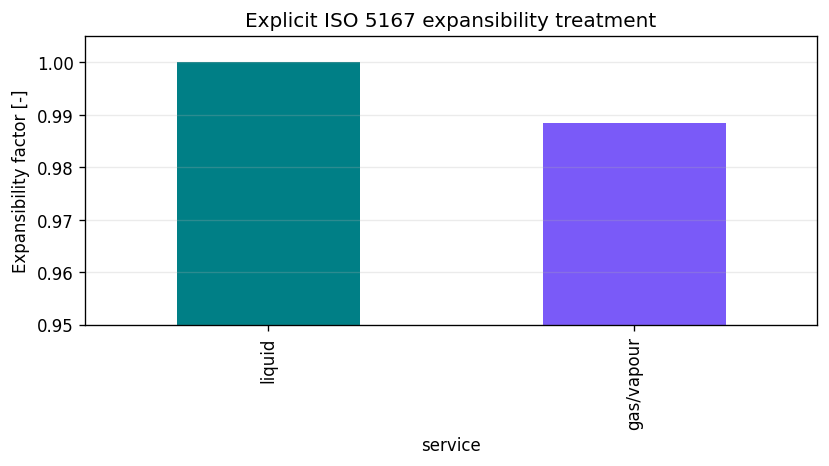

In [3]:
liquid = run_case(ServiceType.LIQUID, 998.0, 0.001).getValue()
rows = [
    {'service': 'liquid', 'epsilon [-]': float(liquid.getExpansibilityFactor()),
     'mass flow [kg/s]': float(liquid.getMassFlowRateKgPerS()),
     'Re_D [-]': float(liquid.getPipeReynoldsNumber())},
    {'service': 'gas/vapour', 'epsilon [-]': float(gas.getExpansibilityFactor()),
     'mass flow [kg/s]': float(gas.getMassFlowRateKgPerS()),
     'Re_D [-]': float(gas.getPipeReynoldsNumber())},
]
comparison = pd.DataFrame(rows)
display(comparison.round(6))

ax = comparison.plot.bar(x='service', y='epsilon [-]', legend=False, color=['#007F86', '#7A5AF8'], figsize=(7, 4))
ax.set_title('Explicit ISO 5167 expansibility treatment')
ax.set_ylim(0.95, 1.005)
ax.set_ylabel('Expansibility factor [-]')
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

## 3. Missing installation evidence fails closed

The next case deliberately omits external geometry and installation verification. The numerical inputs are otherwise identical, but the result is blocked rather than presented as ISO 5167 evidence.

In [4]:
blocked = run_case(ServiceType.GAS_OR_VAPOUR, 5.5, 1.2e-5, 1.30, installation_verified=False)
blockers = [dict(item) for item in blocked.getReadiness().toMap().get('blockers')]
assert str(blocked.getStatus()) == 'BLOCKED'
assert blocked.getValue() is None
pd.DataFrame(blockers)[['code', 'message', 'requiredAction']]

,code,message,requiredAction
0,ISO5167_INSTALLATION_NOT_VERIFIED,"Orifice geometry, pressure tappings, straight ...",Verify the meter against the purchased ISO 516...


## Interpretation

Use the typed result as a traceable single-operating-point screen. A project metering decision still needs verified dimensions at flowing conditions, installed plate/tapping/straight-length evidence, calibration and transmitter range, uncertainty propagation, pulsation and flow-profile review, data validation, and accountable acceptance under the governing metering procedure.